# Arnoldi Alogorithm
Find the eigenvalues of a system using the Arnoldi Algorithm of the ARPACK suite

The generalized standard eigenvalue problem is defined by: 
\begin{equation}
\mathbf{A x} = \lambda \mathbf{M} \mathbf{x}
\end{equation}


Define a system for which we know the analytical eigenvalues. make $\mathbf{A}$ diagonal, and $\mathbf{M} = 2*\mathbf{I}$, for which the eigenvalues are the halves of the diagonal entities of $\mathbf{A}$

In [1]:
import numpy as np
from scipy.sparse.linalg import eigs
import numpy as np
import matplotlib.pyplot as plt

dim = 25  # dimension of the problem. it can be scaled efficiently

# build the diagonal A matrix with random complex entries
real_part = np.random.uniform(-1, 1, dim)
imaginary_part = np.random.uniform(-1, 1, dim)
random_complex_array = real_part + 2j*imaginary_part
eigs_analytical = random_complex_array/2

A = np.diag(random_complex_array) # matrix A
M = np.eye(dim)*2 # matrix M

Use the eigs() method of scipy. Look for the first set of $k$ eigenvalues starting from the initial guess $\sigma$

In [2]:
sigma = 0  # starting point of the research (shift and invert strategy)
k = 10 # k must be lower than dim-1. eigs cannot find the full spectrum. 
eig_val, eig_vec = eigs(A, M=M, k=k, sigma=sigma)

plot the results

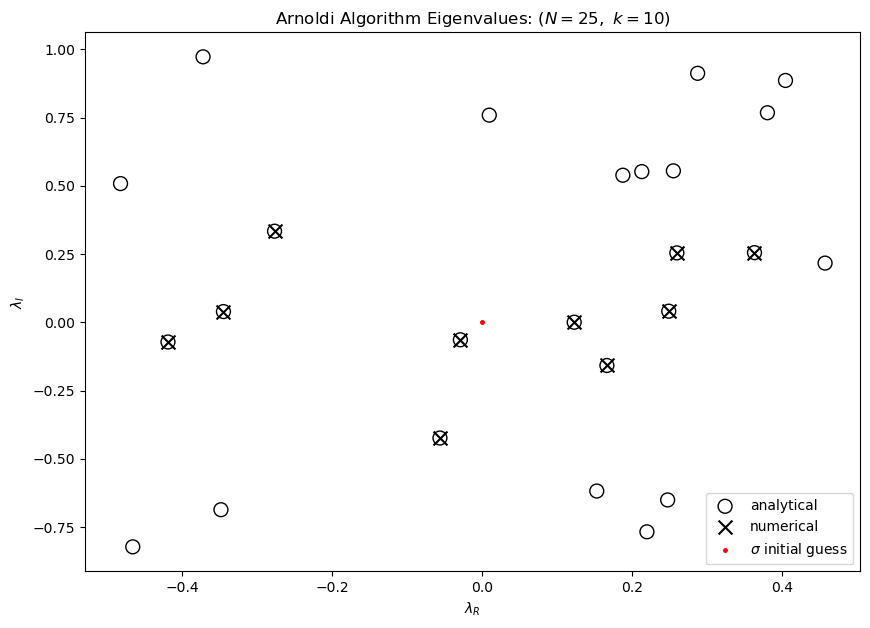

In [3]:
marker_size = 100

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(eigs_analytical.real, eigs_analytical.imag, marker='o', facecolors='none', edgecolors='black',
           s=marker_size, label=r'analytical')
ax.scatter(eig_val.real, eig_val.imag, marker='x', facecolors='black', label=r'numerical', s=marker_size)
ax.scatter(sigma.real, sigma.imag, marker='.', facecolors='red', edgecolors='red', label=r'$\sigma$ initial guess', s=marker_size//4)
ax.set_xlabel(r'$\lambda_{R}$')
ax.set_ylabel(r'$\lambda_{I}$')
ax.set_title(r'Arnoldi Algorithm Eigenvalues: $(N=%d, \ k=%d)$'%(dim, k))
ax.legend()
fig.savefig('eigenvalues_%d_%d.pdf' %(dim, k), bbox_inches='tight')